C:\Users\Utilizador\anaconda3\Lib\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)
C:\Users\Utilizador\anaconda3\Lib\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


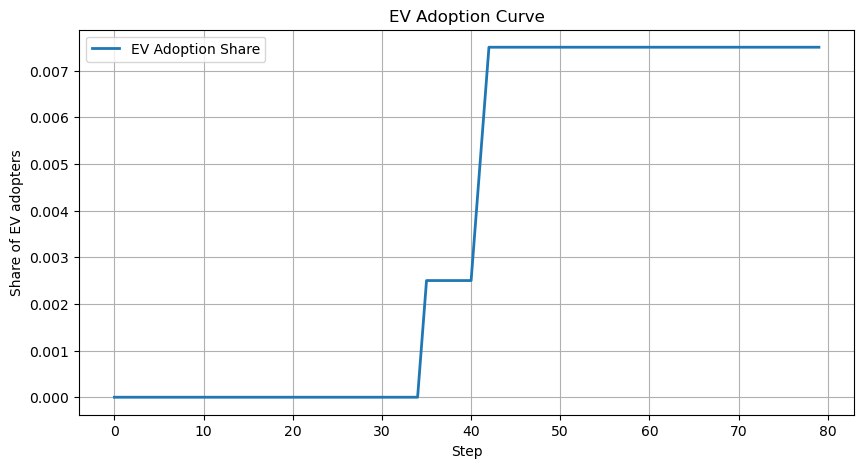

.......                                                                  [100%]
============================== warnings summary ===============================
tests/test_ev_model.py::test_model_runs_10_steps
tests/test_ev_model.py::test_adoption_share_bounds
tests/test_ev_model.py::test_subsidy_monotonicity
tests/test_ev_model.py::test_charging_access_monotonicity
  C:\Users\Utilizador\anaconda3\Lib\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
    res = func(*args, **kwargs)

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html
7 passed, 4 warnings in 1.86s


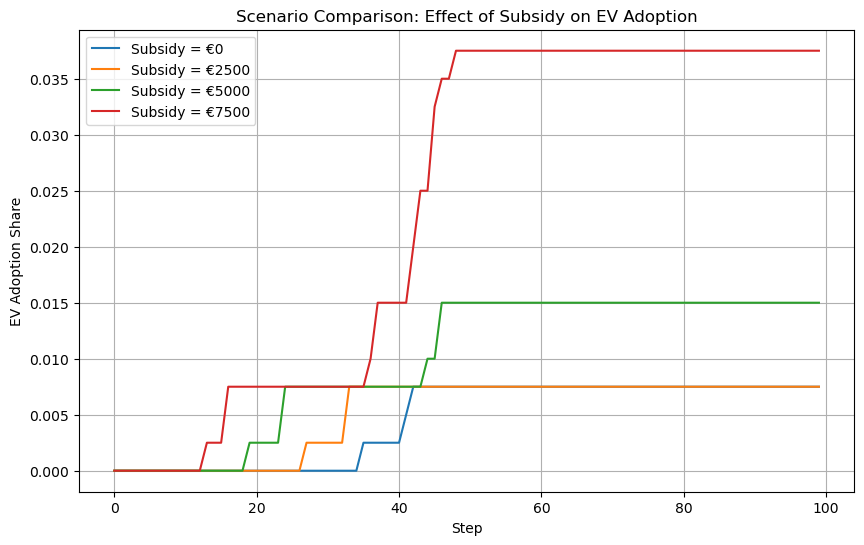

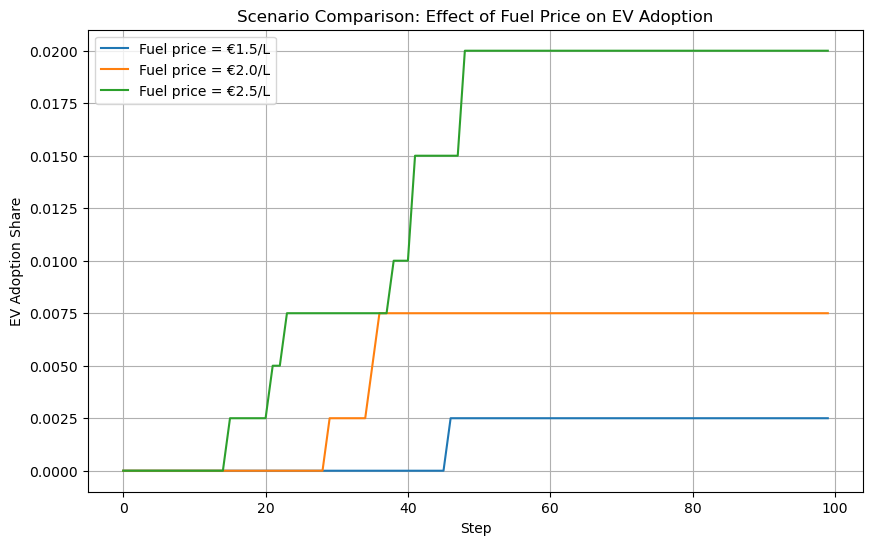

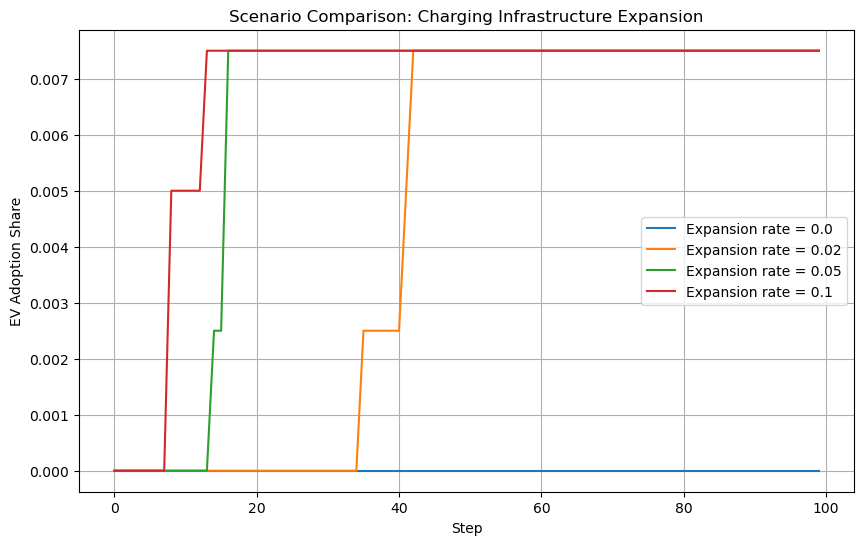

Ran EV model for 50 steps.
Final outcomes:
  EV adoption share: 1.000
  Mean adoption score: 0.268
  Mean charging access: 1.000
  Mean TCO gap (ICE - EV): 5441.29


In [1]:
from affordance_mesa.ev_model import EVAdoptionModel
from affordance_mesa.ev_params import EVParams


params = EVParams(width=10, height=10, subsidy=3000)
model = EVAdoptionModel(params=params, seed=42)
model.step()

model = EVAdoptionModel(EVParams(width=10, height=10), seed=42)

for _ in range(100):
    model.step()

model.ev_adoption_share

model.mean_adoption_score
model.mean_charging_access

sum(a.ev_adopted for a in model.agent_list)

model.ev_adoption_count

model.mean_adoption_score

model.mean_charging_access

model.mean_tco_gap

import matplotlib.pyplot as plt

# 1. Criar modelo
params = EVParams(width=20, height=20)
model = EVAdoptionModel(params, seed=42)

# 2. Correr o modelo
steps = 80
for _ in range(steps):
    model.step()

# 3. Extrair dados
results = model.datacollector.get_model_vars_dataframe()

# 4. Plotar curva de adoção
plt.figure(figsize=(10, 5))
plt.plot(results["ev_adoption_share"], label="EV Adoption Share", linewidth=2)
plt.xlabel("Step")
plt.ylabel("Share of EV adopters")
plt.title("EV Adoption Curve")
plt.grid(True)
plt.legend()
plt.show()

!pytest -q

import matplotlib.pyplot as plt

def run_scenario(subsidy, steps=100):
    params = EVParams(width=20, height=20, subsidy=subsidy)
    model = EVAdoptionModel(params, seed=42)

    for _ in range(steps):
        model.step()

    results = model.datacollector.get_model_vars_dataframe()
    return results["ev_adoption_share"]


subsidies = [0, 2500, 5000, 7500]
curves = {}

for s in subsidies:
    curves[s] = run_scenario(s)

# Plot
plt.figure(figsize=(10, 6))

for s, curve in curves.items():
    plt.plot(curve, label=f"Subsidy = €{s}")

plt.xlabel("Step")
plt.ylabel("EV Adoption Share")
plt.title("Scenario Comparison: Effect of Subsidy on EV Adoption")
plt.legend()
plt.grid(True)
plt.show()

import matplotlib.pyplot as plt

def run_scenario(subsidy, steps=100):
    params = EVParams(width=20, height=20, subsidy=subsidy)
    model = EVAdoptionModel(params, seed=42)

    for _ in range(steps):
        model.step()

    results = model.datacollector.get_model_vars_dataframe()
    return results["ev_adoption_share"]

fuel_prices = [1.5, 2.0, 2.5]
curves_fp = {}

for fp in fuel_prices:
    params = EVParams(width=20, height=20, fuel_price=fp)
    model = EVAdoptionModel(params, seed=42)

    for _ in range(100):
        model.step()

    curves_fp[fp] = model.datacollector.get_model_vars_dataframe()["ev_adoption_share"]

plt.figure(figsize=(10, 6))

for fp, curve in curves_fp.items():
    plt.plot(curve, label=f"Fuel price = €{fp}/L")

plt.xlabel("Step")
plt.ylabel("EV Adoption Share")
plt.title("Scenario Comparison: Effect of Fuel Price on EV Adoption")
plt.legend()
plt.grid(True)
plt.show()

rates = [0.00, 0.02, 0.05, 0.10]
curves_ch = {}

for r in rates:
    params = EVParams(width=20, height=20, charger_expansion_rate=r)
    model = EVAdoptionModel(params, seed=42)

    for _ in range(100):
        model.step()

    curves_ch[r] = model.datacollector.get_model_vars_dataframe()["ev_adoption_share"]

plt.figure(figsize=(10, 6))

for r, curve in curves_ch.items():
    plt.plot(curve, label=f"Expansion rate = {r}")

plt.xlabel("Step")
plt.ylabel("EV Adoption Share")
plt.title("Scenario Comparison: Charging Infrastructure Expansion")
plt.legend()
plt.grid(True)
plt.show()

%run scripts/run_ev_model.py

